In [138]:
import pandas as pd


In [139]:
df = pd.read_csv('World University Rankings 2023-selected-columns.csv')

In [140]:
df

,University Rank,Name of University,Location,No of student,No of student per staff,International Student,Female:Male Ratio,OverAll Score,Teaching Score,Research Score
0,1,University of Oxford,United Kingdom,"20,965",10.6,42%,48 : 52,96.4,92.3,99.7
1,2,Harvard University,United States,"21,887",9.6,25%,50 : 50,95.2,94.8,99.0
2,3,University of Cambridge,United Kingdom,"20,185",11.3,39%,47 : 53,94.8,90.9,99.5
3,3,Stanford University,United States,"16,164",7.1,24%,46 : 54,94.8,94.2,96.7
4,5,Massachusetts Institute of Technology,United States,"11,415",8.2,33%,40 : 60,94.2,90.7,93.6
...,...,...,...,...,...,...,...,...,...,...
2336,-,University of the West of Scotland,NaN,NaN,NaN,NaN,NaN,34.0–39.2,24.1,15.5
2337,-,University of Windsor,NaN,NaN,NaN,NaN,NaN,34.0–39.2,35.1,29.4
2338,-,University of Wolverhampton,NaN,NaN,NaN,NaN,NaN,34.0–39.2,18.2,14.3
2339,-,University of Wuppertal,NaN,NaN,NaN,NaN,NaN,34.0–39.2,26.4,26.7


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   University Rank          2341 non-null   object 
 1   Name of University       2233 non-null   object 
 2   Location                 2047 non-null   object 
 3   No of student            2209 non-null   object 
 4   No of student per staff  2208 non-null   float64
 5   International Student    2209 non-null   object 
 6   Female:Male Ratio        2128 non-null   object 
 7   OverAll Score            1799 non-null   object 
 8   Teaching Score           1799 non-null   float64
 9   Research Score           1799 non-null   float64
dtypes: float64(3), object(7)
memory usage: 183.0+ KB


In [142]:
df.duplicated().sum()

np.int64(29)

In [143]:
df.isnull().sum()

University Rank              0
Name of University         108
Location                   294
No of student              132
No of student per staff    133
International Student      132
Female:Male Ratio          213
OverAll Score              542
Teaching Score             542
Research Score             542
dtype: int64

In [144]:
df['Location']=df['Location'].fillna(df['Location'].mode()[0])

In [145]:
df.isnull().sum()

University Rank              0
Name of University         108
Location                     0
No of student              132
No of student per staff    133
International Student      132
Female:Male Ratio          213
OverAll Score              542
Teaching Score             542
Research Score             542
dtype: int64

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
df['No of student']

0       20,965
1       21,887
2       20,185
3       16,164
4       11,415
         ...  
2336       NaN
2337       NaN
2338       NaN
2339       NaN
2340       NaN
Name: No of student, Length: 2341, dtype: object

In [148]:
df['No of student']=df['No of student'].fillna(df['No of student'].mode()[0])

In [149]:
df['Teaching Score']=df['Teaching Score'].fillna(df['Teaching Score'].mean())

In [150]:
df['OverAll Score']=df['OverAll Score'].fillna(df['OverAll Score'].mode()[0])

In [151]:
df['No of student per staff']=df['No of student per staff'].fillna(df['No of student per staff'].median())

In [152]:
df['International Student']=df['International Student'].fillna(df['International Student'].mode()[0])

In [153]:
df['Female:Male Ratio']=df['Female:Male Ratio'].fillna(df['Female:Male Ratio'].mode()[0])


In [154]:
df['Name of University']=df['Name of University'].fillna(df['Name of University'].mode()[0])

In [155]:
df.describe()

,No of student per staff,Teaching Score,Research Score
count,2341.000000,2341.000000,1799.000000
mean,18.864032,27.018010,23.016898
std,11.795498,11.642824,16.763819
min,0.400000,11.600000,7.400000
25%,12.800000,19.000000,11.300000
50%,16.600000,27.018010,17.000000
75%,21.700000,28.400000,28.900000
max,232.200000,94.800000,99.700000


<Axes: ylabel='No of student per staff'>

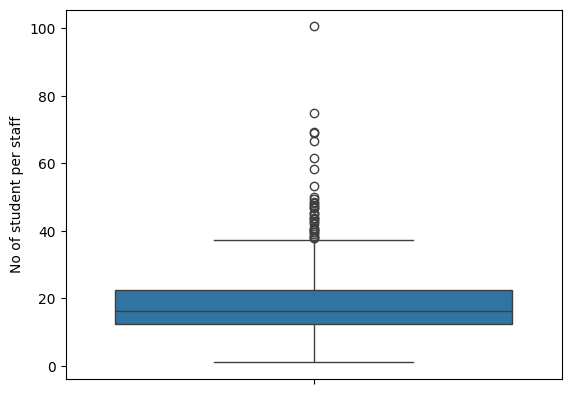

In [156]:
sns.boxplot(df['No of student per staff'].head(700))

<Axes: ylabel='Research Score'>

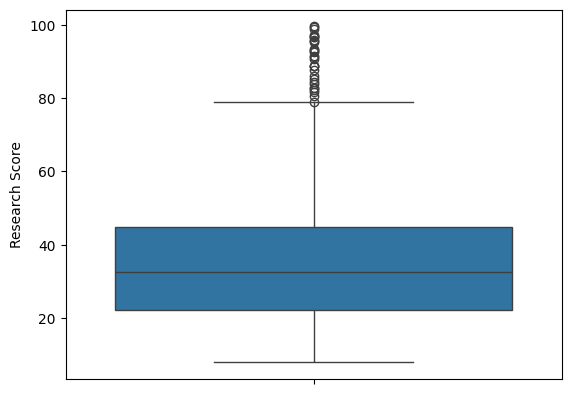

In [157]:
sns.boxplot(df['Research Score'].head(700))

<Axes: ylabel='Teaching Score'>

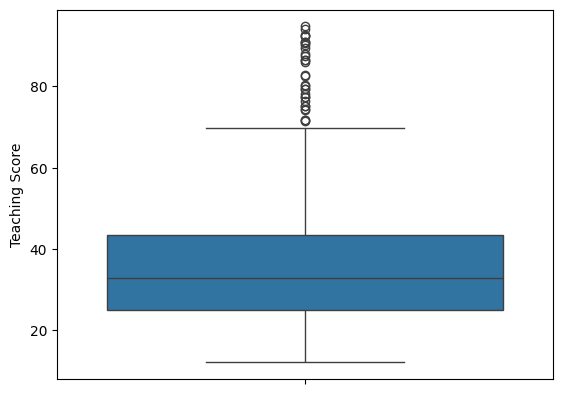

In [158]:
sns.boxplot(df['Teaching Score'].head(700))

In [159]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['No of student per staff']))
df_clean = df[z_scores < 2] 

print(df.describe()) 

       No of student per staff  Teaching Score  Research Score
count              2341.000000     2341.000000     1799.000000
mean                 18.864032       27.018010       23.016898
std                  11.795498       11.642824       16.763819
min                   0.400000       11.600000        7.400000
25%                  12.800000       19.000000       11.300000
50%                  16.600000       27.018010       17.000000
75%                  21.700000       28.400000       28.900000
max                 232.200000       94.800000       99.700000


In [160]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['Teaching Score']))
df_clean = df[z_scores < 2] 

print(df.describe()) 

       No of student per staff  Teaching Score  Research Score
count              2341.000000     2341.000000     1799.000000
mean                 18.864032       27.018010       23.016898
std                  11.795498       11.642824       16.763819
min                   0.400000       11.600000        7.400000
25%                  12.800000       19.000000       11.300000
50%                  16.600000       27.018010       17.000000
75%                  21.700000       28.400000       28.900000
max                 232.200000       94.800000       99.700000


In [161]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['Research Score']))
df_clean = df[z_scores < 2] 

print(df_clean.describe()) 

       No of student per staff  Teaching Score  Research Score
count                      0.0             0.0             0.0
mean                       NaN             NaN             NaN
std                        NaN             NaN             NaN
min                        NaN             NaN             NaN
25%                        NaN             NaN             NaN
50%                        NaN             NaN             NaN
75%                        NaN             NaN             NaN
max                        NaN             NaN             NaN


<Axes: >

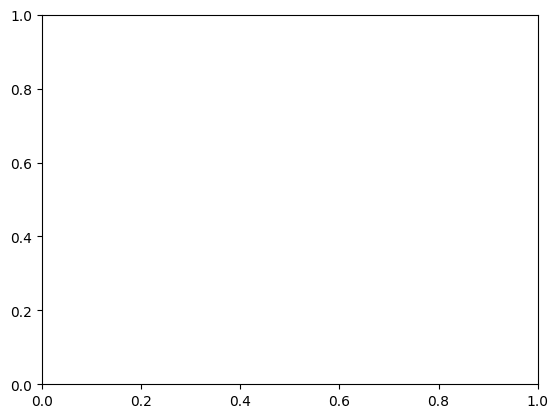

In [162]:
sns.kdeplot(df_clean['Research Score'])

<Axes: >

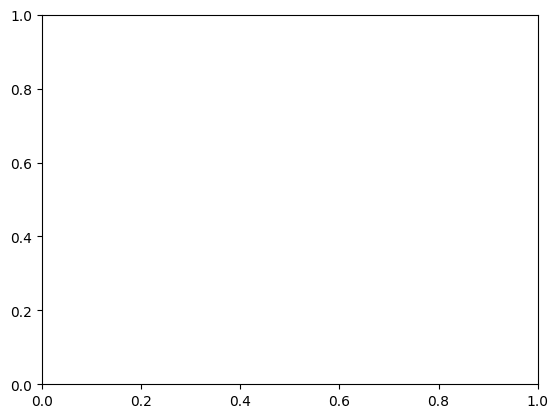

In [163]:
sns.boxplot(df_clean['Research Score'])

In [164]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))


Original rows: 2341
Cleaned rows: 0
Rows removed: 2341


In [165]:
df.isnull().sum()

University Rank              0
Name of University           0
Location                     0
No of student                0
No of student per staff      0
International Student        0
Female:Male Ratio            0
OverAll Score                0
Teaching Score               0
Research Score             542
dtype: int64

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   University Rank          2341 non-null   object 
 1   Name of University       2341 non-null   object 
 2   Location                 2341 non-null   object 
 3   No of student            2341 non-null   object 
 4   No of student per staff  2341 non-null   float64
 5   International Student    2341 non-null   object 
 6   Female:Male Ratio        2341 non-null   object 
 7   OverAll Score            2341 non-null   object 
 8   Teaching Score           2341 non-null   float64
 9   Research Score           1799 non-null   float64
dtypes: float64(3), object(7)
memory usage: 183.0+ KB


In [167]:
df.drop(columns='Female:Male Ratio', inplace = True)
df.drop(columns='No of student per staff', inplace=True)
# dropped after corr -> for more check 'main.ipynb' file

In [168]:
df.isnull().sum()

University Rank            0
Name of University         0
Location                   0
No of student              0
International Student      0
OverAll Score              0
Teaching Score             0
Research Score           542
dtype: int64

In [169]:
df['Research Score']=df['Research Score'].fillna(df['Research Score'].mean())

In [170]:
from sklearn.preprocessing import OrdinalEncoder
o = OrdinalEncoder()

df[['University Rank']] = o.fit_transform(df[['University Rank']])
df[['Name of University']] = o.fit_transform(df[['Name of University']])
df[['Location']] = o.fit_transform(df[['Location']])
df[['No of student']] = o.fit_transform(df[['No of student']])
df[['International Student']] = o.fit_transform(df[['International Student']])

In [171]:
from sklearn.preprocessing import LabelEncoder
o = LabelEncoder()
df['OverAll Score'] = o.fit_transform(df['OverAll Score'])

In [172]:
# Model Train adn LinearRegression

In [173]:
df

,University Rank,Name of University,Location,No of student,International Student,OverAll Score,Teaching Score,Research Score
0,1.0,1886.0,108.0,806.0,39.0,159,92.3,99.7
1,75.0,504.0,109.0,847.0,20.0,158,94.8,99.0
2,87.0,1625.0,108.0,771.0,35.0,157,90.9,99.5
3,87.0,1266.0,109.0,493.0,19.0,157,94.2,96.7
4,111.0,826.0,109.0,192.0,29.0,156,90.7,93.6
...,...,...,...,...,...,...,...,...
2336,0.0,2083.0,109.0,0.0,1.0,4,24.1,15.5
2337,0.0,2049.0,109.0,0.0,1.0,4,35.1,29.4
2338,0.0,2053.0,109.0,0.0,1.0,4,18.2,14.3
2339,0.0,2056.0,109.0,0.0,1.0,4,26.4,26.7


In [174]:
x = df.drop(columns='OverAll Score')
y = df['OverAll Score']

In [175]:
df.shape

(2341, 8)

In [176]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=100)

In [177]:
# linearreg - train

In [178]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_train)

In [179]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_train, y_pred))
print(mean_absolute_error(y_train, y_pred))

0.7472847960092228
8.692491901981361


In [180]:
# linearreg - test

In [181]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [182]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.6996987835671918
8.626202076459144


In [183]:
# randomforest - train

In [184]:
from sklearn.ensemble import RandomForestRegressor
rc = RandomForestRegressor()
rc.fit(x_train, y_train)
y_pred = rc.predict(x_train)
y_pred

array([ 1.  ,  3.  ,  0.  , ..., 85.06,  1.  ,  0.  ], shape=(1872,))

In [185]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_train, y_pred))
print(mean_absolute_error(y_train, y_pred))

0.9970501580729954
0.20080128205128198


In [186]:
# randomforest - test

In [187]:
from sklearn.ensemble import RandomForestRegressor
rc = RandomForestRegressor()
rc.fit(x_train, y_train)
y_pred = rc.predict(x_test)

In [188]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.9905897296827888
0.3778038379530917


In [189]:
# DecisionTree - training

In [190]:
from sklearn.tree import DecisionTreeRegressor
lr = DecisionTreeRegressor()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_train)

In [191]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_train, y_pred))
print(mean_absolute_error(y_train, y_pred))

1.0
0.0


In [192]:
# DecisionTree - testing

In [193]:
from sklearn.tree import DecisionTreeRegressor
lr = DecisionTreeRegressor()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)


In [194]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.9765117875611722
0.42857142857142855


In [195]:
# KNN - training

In [196]:
from sklearn.neighbors import KNeighborsRegressor
lr = KNeighborsRegressor()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_train)

In [197]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_train, y_pred))
print(mean_absolute_error(y_train, y_pred))

0.4360076216433534
7.395726495726495


In [198]:
# KNN - testing

In [199]:
from sklearn.neighbors import KNeighborsRegressor
lr = KNeighborsRegressor()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)


In [200]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.1501475756649152
8.356503198294243


In [201]:
# SVR - Training

In [202]:
from sklearn.svm import SVR
lr = SVR()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_train)

In [203]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_train, y_pred))
print(mean_absolute_error(y_train, y_pred))

-0.06430148182062734
8.0907530791176


In [204]:
# SVR - Testing

In [205]:
from sklearn.svm import SVR
lr = SVR()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

In [206]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

-0.061730221213861736
7.372139952615147
